# Vector Databases — what ANN search actually does

**Notebook 05 · Phase 2 (Retrieval foundations)** · Trio: **FAISS → Chroma → Pinecone**

Embeddings (Notebook 04) gave us vectors. A **vector database's** real job is
**Approximate Nearest Neighbor (ANN) search**: instead of comparing your query against
*every* stored vector (exact / brute-force — accurate but scales terribly), it builds an
**index** (e.g. **HNSW** graphs or **IVF** inverted files) that finds "close enough"
neighbors in milliseconds across millions of vectors — trading a little **recall** for huge
**speed**. That speed-vs-accuracy knob is the whole game.

We climb the same concept three times:

1. **FAISS** — *not a database*, just a library. Build and inspect an HNSW/IVF index yourself
   to see ANN mechanics in the raw.
2. **Chroma** — that same ANN logic wrapped in an **embedded database** (metadata filtering,
   persistence, simple API), zero infra. The "local/dev, feels like a real project" choice.
3. **Pinecone** — **managed, serverless, zero-ops** production. No infra, but a hosted cost
   and vendor dependency — exactly the trade-off to weigh before a client project.

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install.

In [1]:
%pip install -q \
    "numpy<2" \
    faiss-cpu chromadb pinecone \
    langchain-openai python-dotenv matplotlib tiktoken
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup

In [2]:
import warnings, os, time, tempfile
warnings.filterwarnings("ignore")
import logging
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
for _n in ("httpx", "openai", "httpcore", "chromadb"):
    logging.getLogger(_n).setLevel(logging.ERROR)
os.environ.setdefault("ANONYMIZED_TELEMETRY", "False")  # quiet Chroma telemetry
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt

load_dotenv(Path.cwd().parent / ".env")
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")  # 1536-dim, used in the Chroma/Pinecone parts

print("OPENAI_API_KEY set  :", bool(os.getenv("OPENAI_API_KEY")))
print("PINECONE_API_KEY set:", bool(os.getenv("PINECONE_API_KEY")), "(Pinecone part is skipped if False)")

OPENAI_API_KEY set  : True
PINECONE_API_KEY set: True (Pinecone part is skipped if False)


## 2. FAISS — ANN mechanics in the raw

FAISS runs in-process with zero setup, so we can build the index ourselves. We create a
synthetic dataset (50,000 vectors), get the **exact** answer by brute force, then see how
**HNSW** and **IVF** approximate it — and how their tuning knobs move the recall/speed
trade-off.

In [3]:
import faiss
faiss.omp_set_num_threads(1)
rng = np.random.default_rng(0)
d, N, nq, k = 128, 50_000, 200, 10  # 128-dim vectors, 50k chunk , 200 queries, top-10 neighbors
xb = rng.standard_normal((N, d)).astype("float32")   # the "chunk" vectors
xq = rng.standard_normal((nq, d)).astype("float32")  # query vectors

# EXACT search (brute force) — the ground truth every ANN index is measured against.
flat = faiss.IndexFlatL2(d)
flat.add(xb)
t0 = time.perf_counter(); _, I_exact = flat.search(xq, k)
t_exact = (time.perf_counter() - t0) / nq * 1000
print(f"IndexFlatL2 (exact): searches all {N:,} vectors → {t_exact:.3f} ms/query (100% recall by definition)")

def recall_at_k(I_approx, I_true=I_exact):
    return float(np.mean([len(set(a) & set(t)) / k for a, t in zip(I_approx, I_true)]))

IndexFlatL2 (exact): searches all 50,000 vectors → 0.087 ms/query (100% recall by definition)


### 2a. HNSW — a navigable graph

HNSW builds a layered proximity graph and greedily walks it toward the query. `efSearch`
controls how widely it explores at query time: **higher = more recall, slower**.

In [4]:
hnsw = faiss.IndexHNSWFlat(d, 32)      # M=32 neighbors per node
hnsw.hnsw.efConstruction = 200          # build-time quality
hnsw.add(xb)

hnsw_curve = []
print("HNSW — efSearch knob:")
for ef in [16, 32, 64, 128, 256]:
    hnsw.hnsw.efSearch = ef
    t0 = time.perf_counter(); _, I = hnsw.search(xq, k); ms = (time.perf_counter() - t0) / nq * 1000
    r = recall_at_k(I)
    hnsw_curve.append((ms, r))
    print(f"  efSearch={ef:3d}  recall@10={r:.3f}  {ms:.3f} ms/query")

HNSW — efSearch knob:
  efSearch= 16  recall@10=0.428  0.067 ms/query
  efSearch= 32  recall@10=0.591  0.121 ms/query
  efSearch= 64  recall@10=0.758  0.183 ms/query
  efSearch=128  recall@10=0.898  0.387 ms/query
  efSearch=256  recall@10=0.965  0.821 ms/query


### 2b. IVF — inverted file (cluster then probe)

IVF partitions vectors into `nlist` clusters (Voronoi cells); at query time it only searches
the `nprobe` nearest clusters. **Higher `nprobe` = more clusters checked = more recall, slower.**
It must be `train()`-ed first to learn the clusters.

In [5]:
quantizer = faiss.IndexFlatL2(d)
ivf = faiss.IndexIVFFlat(quantizer, d, 256)   # nlist = 256 clusters
ivf.train(xb)                                  # learn cluster centroids
ivf.add(xb)

ivf_curve = []
print("IVF — nprobe knob (nlist=256):")
for nprobe in [1, 4, 16, 64, 128]:
    ivf.nprobe = nprobe
    t0 = time.perf_counter(); _, I = ivf.search(xq, k); ms = (time.perf_counter() - t0) / nq * 1000
    r = recall_at_k(I)
    ivf_curve.append((ms, r))
    print(f"  nprobe={nprobe:3d}  recall@10={r:.3f}  {ms:.3f} ms/query")

IVF — nprobe knob (nlist=256):
  nprobe=  1  recall@10=0.038  0.021 ms/query
  nprobe=  4  recall@10=0.112  0.025 ms/query
  nprobe= 16  recall@10=0.278  0.075 ms/query
  nprobe= 64  recall@10=0.637  0.282 ms/query
  nprobe=128  recall@10=0.873  0.552 ms/query


### 2c. The recall–speed trade-off, visualized

Every ANN index gives you a curve like this. You pick the operating point your product needs
(e.g. "recall@10 ≥ 0.95 at the lowest latency"). The exact index is the dashed 100%-recall
reference — note how much faster ANN is for a small recall sacrifice.

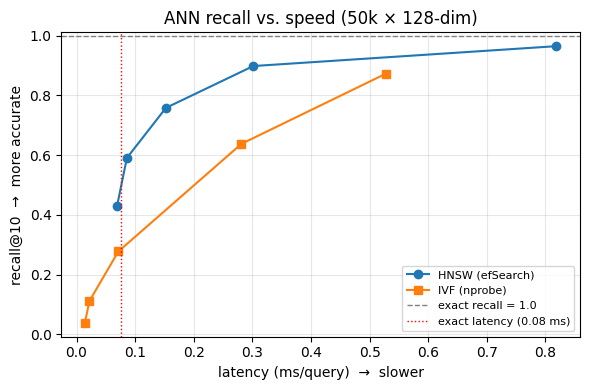

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
hx, hy = zip(*hnsw_curve); ix, iy = zip(*ivf_curve)
ax.plot(hx, hy, "o-", label="HNSW (efSearch)")
ax.plot(ix, iy, "s-", label="IVF (nprobe)")
ax.axhline(1.0, ls="--", color="gray", lw=1, label="exact recall = 1.0")
ax.axvline(t_exact, ls=":", color="red", lw=1, label=f"exact latency ({t_exact:.2f} ms)")
ax.set_xlabel("latency (ms/query)  →  slower"); ax.set_ylabel("recall@10  →  more accurate")
ax.set_title("ANN recall vs. speed (50k × 128-dim)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Takeaway (Part A):** ANN indexes trade a little recall for a large speed gain, and
`efSearch` (HNSW) / `nprobe` (IVF) are the dials. On real corpora HNSW usually gives the best
recall-per-millisecond, which is why most vector DBs — including Chroma below — use it by
default. You rarely call FAISS directly in production, but knowing this is what's under the
hood is what lets you tune a vector DB instead of treating it as a black box.

## 3. Chroma — the same ANN, now an embedded database

Chroma wraps HNSW in a real (embedded) database: it stores your **documents**, **metadata**,
and **embeddings** together, adds **metadata filtering** and **persistence**, and gives you a
simple Python API — with zero infrastructure to run. We supply our **own OpenAI embeddings**
(reinforcing Notebook 04's rule: index and query with the *same* model).

In [13]:
import chromadb

# A small corpus with metadata to filter on.
docs = [
    ("Refunds are processed within 5 business days.",            {"topic": "billing",   "year": 2024}),
    ("To cancel your subscription, visit account settings.",     {"topic": "billing",   "year": 2023}),
    ("Standard shipping takes 3 to 5 business days.",            {"topic": "logistics", "year": 2024}),
    ("Expedited shipping is available in the West region.",      {"topic": "logistics", "year": 2024}),
    ("Employees get a $45 monthly home-internet stipend.",       {"topic": "hr",        "year": 2024}),
    ("Remote workers must be online during core hours.",         {"topic": "hr",        "year": 2023}),
]
texts = [d[0] for d in docs]
metas = [d[1] for d in docs]
ids   = [f"doc-{i}" for i in range(len(docs))]
vecs  = embeddings.embed_documents(texts)   # OpenAI 3-small, 1536-dim

client = chromadb.Client()  # in-memory; use PersistentClient(path=...) to save to disk
col = client.get_or_create_collection("knowledge_base", metadata={"hnsw:space": "ip"})
col.add(embeddings=vecs, documents=texts, metadatas=metas, ids=ids)
print("collection count:", col.count())

collection count: 6


In [14]:
client.get_or_create_collection?

Signature:
client.get_or_create_collection(
    name: str,
    schema: Optional[chromadb.api.types.Schema] = None,
    configuration: Optional[chromadb.api.collection_configuration.CreateCollectionConfiguration] = None,
    metadata: Optional[Dict[str, Any]] = None,
    embedding_function: Optional[chromadb.api.types.EmbeddingFunction[Union[List[str], List[numpy.ndarray[Any, numpy.dtype[Union[numpy.uint64, numpy.int64, numpy.float64]]]]]]] = <chromadb.api.types.DefaultEmbeddingFunction object at 0x327952390>,
    data_loader: Optional[chromadb.api.types.DataLoader[List[Optional[numpy.ndarray[Any, numpy.dtype[Union[numpy.uint64, numpy.int64, numpy.float64]]]]]]] = None,
) -> chromadb.api.models.Collection.Collection
Docstring:
Get an existing collection or create a new one.

If the collection does not exist, it will be created. If the collection
already exists, the schema, configuration, and metadata arguments
will be ignored.

Args:
    name: Collection name.
    schema: Optional colle

### 3a. Semantic search

Embed the query with the **same** model, then let Chroma's ANN index find the nearest docs.

In [15]:
qvec = embeddings.embed_query("How do I get my money back?")
res = col.query(query_embeddings=[qvec], n_results=3)
for doc, dist in zip(res["documents"][0], res["distances"][0]):
    print(f"  dist={dist:.3f}  {doc}")

  dist=0.643  Refunds are processed within 5 business days.
  dist=0.789  To cancel your subscription, visit account settings.
  dist=0.840  Employees get a $45 monthly home-internet stipend.


In [19]:
qvec = embeddings.embed_query("what do remote employees get?")
res = col.query(query_embeddings=[qvec], n_results=3)
for doc, dist in zip(res["documents"][0], res["distances"][0]):
    print(f"  dist={dist:.3f}  {doc}")

  dist=0.467  Employees get a $45 monthly home-internet stipend.
  dist=0.558  Remote workers must be online during core hours.
  dist=0.810  Expedited shipping is available in the West region.


In [30]:
qvec = embeddings.embed_query("I dont need the my monthly membership?")
res = col.query(query_embeddings=[qvec], n_results=3, where={"$and": [{"topic": "hr"}, {"year": 2024}]})
for doc, dist in zip(res["documents"][0], res["distances"][0]):
    print(f"  dist={dist:.3f}  {doc}")

  dist=0.721  Employees get a $45 monthly home-internet stipend.


### 3b. Metadata filtering

The killer feature over a raw FAISS index: constrain the search with a `where` filter — here,
only `hr` documents from 2024. This is how you enforce tenants, recency, or ACLs in production.

In [8]:
qvec = embeddings.embed_query("what do remote employees get?")
res = col.query(
    query_embeddings=[qvec],
    n_results=3,
    where={"$and": [{"topic": "hr"}, {"year": 2024}]},
)
print("filtered (topic=hr AND year=2024):")
for doc, meta in zip(res["documents"][0], res["metadatas"][0]):
    print(f"  {meta}  {doc}")

filtered (topic=hr AND year=2024):
  {'year': 2024, 'topic': 'hr'}  Employees get a $45 monthly home-internet stipend.


### 3c. Persistence

`PersistentClient(path=...)` writes the index to disk so it survives restarts — reconnect and
the data is still there. No server to run.

In [9]:
persist_dir = tempfile.mkdtemp(prefix="chroma_")
pc_client = chromadb.PersistentClient(path=persist_dir)
pcol = pc_client.get_or_create_collection("knowledge_base", metadata={"hnsw:space": "cosine"})
pcol.add(embeddings=vecs, documents=texts, metadatas=metas, ids=ids)
del pc_client, pcol                               # simulate process exit

reopened = chromadb.PersistentClient(path=persist_dir).get_collection("knowledge_base")
print(f"reconnected to {persist_dir}")
print("count after reopen:", reopened.count(), "→ data persisted ✅")

reconnected to /var/folders/cv/kmsppstx0d9281mtbqrrgl6c0000gn/T/chroma_cfpyh2ou
count after reopen: 6 → data persisted ✅


**Takeaway (Part B):** Chroma gives you production-shaped ergonomics — documents + metadata +
filtering + persistence — on the same HNSW ANN core, with nothing to deploy. Ideal for local
dev and small/mid projects.

## 4. Pinecone — managed, serverless, zero-ops production

Pinecone runs the vector database *for* you: no infra, serverless scaling, built-in metadata
filtering and **namespaces** (isolated partitions within an index). The trade-off is a hosted
**cost** and a **vendor dependency**.

The cell below runs **only if `PINECONE_API_KEY` is set** (get one free at pinecone.io). With
no key it prints a note and skips — the reference code is shown so you can run it later.

In [ ]:
if os.getenv("PINECONE_API_KEY"):
    from pinecone import Pinecone, ServerlessSpec
    pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
    name = "rag-demo-05"

    existing = pc.list_indexes().names()
    if name not in existing:
        pc.create_index(name=name, dimension=1536, metric="cosine",
                        spec=ServerlessSpec(cloud="aws", region="us-east-1"))
    index = pc.Index(name)

    # Upsert with metadata + namespace
    index.upsert(
        vectors=[(ids[i], vecs[i], metas[i]) for i in range(len(texts))],
        namespace="faq",
    )
    # serverless indexes are eventually consistent — wait until vectors are queryable
    for _ in range(30):
        ns = index.describe_index_stats().namespaces.get("faq")
        if ns and ns.vector_count >= len(texts):
            break
        time.sleep(1)

    qvec = embeddings.embed_query("How do I get my money back?")
    r = index.query(vector=qvec, top_k=3, include_metadata=True,
                    filter={"topic": "billing"}, namespace="faq")
    print("Pinecone query (filter topic=billing):")
    for m in r.matches:
        print(f"  score={m.score:.3f}  {r} {m.metadata}")

    pc.delete_index(name)   # clean up so the demo leaves no hosted resources
    print("Pinecone demo complete; index deleted.")
else:
    print("PINECONE_API_KEY not set → skipping live Pinecone calls.")
    print("Add it to your .env to run this section. Reference code is in the next cell.")

Pinecone query (filter topic=billing):
  score=0.356  {'matches': [{'id': 'doc-0',
              'metadata': {'topic': 'billing', 'year': 2024.0},
              'score': 0.356467187,
              'values': []},
             {'id': 'doc-1',
              'metadata': {'topic': 'billing', 'year': 2023.0},
              'score': 0.210236728,
              'values': []}],
 'namespace': 'faq',
 'usage': {'read_units': 1}} {'topic': 'billing', 'year': 2024.0}
  score=0.210  {'matches': [{'id': 'doc-0',
              'metadata': {'topic': 'billing', 'year': 2024.0},
              'score': 0.356467187,
              'values': []},
             {'id': 'doc-1',
              'metadata': {'topic': 'billing', 'year': 2023.0},
              'score': 0.210236728,
              'values': []}],
 'namespace': 'faq',
 'usage': {'read_units': 1}} {'topic': 'billing', 'year': 2023.0}


### Reference: the Pinecone pattern (current SDK)

```python
from pinecone import Pinecone, ServerlessSpec
pc = Pinecone(api_key="...")

pc.create_index(                       # serverless index, zero infra
    name="rag-demo", dimension=1536, metric="cosine",
    spec=ServerlessSpec(cloud="aws", region="us-east-1"),
)
index = pc.Index("rag-demo")

index.upsert(                          # (id, values, metadata) tuples
    vectors=[("doc-0", vec, {"topic": "billing"})],
    namespace="faq",                   # namespaces isolate partitions in one index
)

index.query(vector=qvec, top_k=5, include_metadata=True,
            filter={"topic": "billing"}, namespace="faq")
```

**Takeaway (Part C):** same query-a-vector concept as FAISS and Chroma, but Pinecone owns the
infra and scales to production traffic. You pay in dollars and lock-in instead of ops time.

## 5. Choosing a vector store

Same ANN core underneath — the decision is about **ops, scale, and features**.

| Option | What it is | Reach for it when |
|--------|-----------|-------------------|
| **FAISS** | In-process library (no DB) | You need raw speed/control, or to learn/prototype ANN; no metadata/persistence out of the box |
| **Chroma** | Embedded DB, zero infra | Local dev and small/mid projects that want filtering + persistence with a simple API |
| **Pinecone** | Managed serverless DB | Production, zero-ops, scale — and you accept hosted cost + vendor lock-in |
| **pgvector** | Postgres extension | You already run Postgres — don't add a new system just for vectors |
| **Qdrant / Weaviate** | Self-host or managed | Strong metadata filtering / hybrid search; sweet spot under ~50M vectors |
| **Milvus** | Distributed DB | Billions of vectors; heavy but genuinely horizontally scalable |

### What we proved
- A vector DB's core job is **ANN search** — approximate, index-backed nearest neighbors.
- **HNSW `efSearch`** and **IVF `nprobe`** are the recall-vs-speed dials; we plotted the curve.
- **FAISS → Chroma → Pinecone** is the same concept at three levels of "done for you":
  raw library → embedded DB → managed service.
- Match the store to **ops capacity, scale, and filtering needs**, not to a leaderboard.

### Next
We can now index and search. The final RAG pieces: **retrieval strategies + reranking**
(hybrid dense+sparse search, cross-encoder rerankers) and wiring it all into a grounded,
cited answer.